# HW02-2：房地产上市公司财务特征分析

| 项目 | 内容 |
|---|---|
| 姓名 | 朱家瑞 |
| 学号 | 23347105 |
| 作业简介或教师作业页面链接 | https://lianxhcn.github.io/FinEco/exercises/hw-02.html |
| 个人 GitHub 仓库访问地址 | https://github.com/Jaremy112/fineco-homework |
| HW02-1 目录链接 | https://github.com/Jaremy112/fineco-homework/tree/main/hw02-1 |
| HW02-2 目录链接 | https://github.com/Jaremy112/fineco-homework/tree/main/hw02-2 |
| 数据来源、获取日期与样本期间 | CSMAR（国泰安）数据中心 https://data.csmar.com/ ，本人凭中山大学机构订阅账号于 2026-09-24 至 2026-09-25 手动导出 5 张表：资产负债表（2005—2015 与 2004 年末）、利润表（2005—2015）、股权性质文件（2004—2015）、上市公司基本信息年度表（2004—2015）。样本期间 2005—2015 各会计年度，另取 2004 年末数据用于平均总资产/权益的期初分母。原始文件属受限数据，不入公开仓库；下载条件、字段清单与单位见同目录 DATA_MANIFEST.md、data/README.md 与 field_mapping.csv |
| 作业网站（首页与本题页面） | https://jaremy112.github.io/fineco-homework/ ｜ https://jaremy112.github.io/fineco-homework/hw02-2.html |
| AI 使用声明 | 使用了 WorkBuddy（Hermes Agent）辅助核对作业口径、编写数据处理代码与审计脚本；全部数据由本人手动从 CSMAR 导出。变量口径、样本取舍与结论由本人核定，详见文末"AI 使用声明" |

## 分析目的与总体思路

本题考察 2005—2015 年房地产 A 股上市公司的数量、产权结构与财务特征。思路分四步：第一步，把 5 张 CSMAR 原始表统一清洗为"企业—年度"非平衡面板（合并报表、年末记录、A 股），行业身份按当年证监会分类逐年判定（2001 版 J\* / 2012 版 K70），产权按当年实际控制人性质分为国有、民营、其他、不明四类；第二步，逐年统计公司总数与产权结构； 第三步，按作业统一口径计算六项财务指标（资产负债率、bankloan、短期负债占比、ROA、ROE、Cash\_TA）； 第四步，对每项指标给出全样本均值与中位数时序、国有与民营的均值与中位数比较、年度有效样本量，并对离群值做保留、标识与剔除前后敏感性比较。全部处理遵循"说明—代码与实际输出—结果解读"结构。

## 样本筛选路线图（每一步剔除了什么）

从原始下载到最终分析样本，共经历以下筛选，每一步的剔除对象与理由如下（精确行数见文末"样本处理表"）：

| 步骤 | 保留/剔除 | 理由 |
|---|---|---|
| ① 合并报表 | 只保留 `Typrep=A`； 剔除 母公司报表（B） | 作业要求年度合并报表；母公司口径与合并口径差异巨大（如万科 2015 母公司净利润 99.5 亿 vs 合并 259.5 亿） |
| ② 年末记录 | 只保留 `Accper` 为 12-31 的记录； 剔除 季报与 01-01 期初行 | 作业要求年度数据；季报/期初行不是年度报表 |
| ③ A 股 |  剔除 B 股（代码 200/900 前缀，共 5 家：帝贤B、雷伊B、新城B股、凌云B股等） | 作业明确研究对象为"房地产 A 股 上市公司"；按代码前缀剔除，不依赖简称 |
| ④ 行业身份 |  剔除 当年不属于房地产业的公司观测（约 645 个观测） | 候选池是"任一年曾属 J01"的 170 家，其中 13 家（华侨城A、张江高科、鲁能泰山等园区/转型公司）在样本期内从未再归入房地产；行业按当年证监会分类逐年判定（2011 及以前 J\*，2012 起 K70），不用当前行业回填历史 |
| ⑤ 上市前报表 | 剔除 早于首次上市年份的观测（合肥城建 2007 年报，2008 年才上市） | 按"各年年末上市状态"构建面板，未上市公司不应进入当年样本 |
| ⑥ 产权缺失 |  不剔除，归入"不明"类 | 作业允许不明类别；招商积余（001914）全期无股权性质记录，删除公司会损失样本 |
| ⑦ 负权益等极端值 |  不剔除，保留并标识，另做剔除前后敏感性比较 | 属真实财务状况（资不抵债 ST 公司），删除会扭曲行业杠杆的真实分布；影响用中位数与敏感性分析控制 |

此外两点不作为"剔除"但影响可用样本：ROA/ROE 需要 2004 年末或上年末数据，公司面板首年（IPO 当年）天然缺上年末分母，对应指标记为缺失（9 个观测），不填补；零分母（如总负债为 0）同样记缺失而非填零。

## 一、样本与字段：从 5 张 CSMAR 原始表到统一读取

 要回答的问题：5 张原始表各自覆盖什么、主键是否唯一、能否支撑"企业—年度"面板。

 做法与口径：
- 原始文件位于本目录 `data/raw/`（受限数据，不入公开仓库），Notebook 以相对路径读取；
- 每张表保留 CSMAR 原始字段，分析变量对照见 `field_mapping.csv`；
- 金额单位为 元（已用万科 2015 年年报数值核验）；
- 导出条件、下载日期与数据版本见 `DATA_MANIFEST.md`。

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文与负号正常显示（作业要求）
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200)

# 数据目录定位：首选相对路径（本目录 data/raw）；从仓库根等目录打开时自动回退
_SUB = " 2005—2015 年房地产 A 股上市公司年度数据"
for _cand in [Path("data/raw") / _SUB,
              Path("hw02-2/data/raw") / _SUB,
              Path("../hw02-2/data/raw") / _SUB]:
    if (_cand / "资产负债表补充/FS_Combas.json").exists():
        RAW = _cand
        break
else:
    raise FileNotFoundError("未找到 CSMAR 原始数据目录；请将工作目录切到 hw02-2/ 后 Restart & Run All")
print("数据目录:", RAW)

def read_json(p):
    """逐行读取 CSMAR 导出的 NDJSON。"""
    with open(p, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

bs   = read_json(RAW / "资产负债表补充/FS_Combas.json")     # 2005—2015 资产负债表
bs04 = read_json(RAW / "资产负债表补充/04/FS_Combas.json")   # 2004 年末（平均分母支持）
inc  = read_json(RAW / "利润表补充/FS_Comins.json")          # 2005—2015 利润表
own  = read_json(RAW / "股权性质/补充/EN_EquityNatureAll.json")  # 逐年股权性质
ann  = read_json(RAW / "行业分类表/STK_LISTEDCOINFOANL.json")    # 年度表：行业+上市状态

print("资产负债表:", bs.shape, "| 04年资产负债表:", bs04.shape,
      "| 利润表:", inc.shape, "| 股权性质:", own.shape, "| 年度表:", ann.shape)
print("\n年度表年份范围:", ann["EndDate"].min(), "~", ann["EndDate"].max(),
      "| 家数:", ann["Symbol"].nunique())

数据目录: data/raw/ 2005—2015 年房地产 A 股上市公司年度数据


资产负债表: (18044, 154) | 04年资产负债表: (1530, 154) | 利润表: (18089, 81) | 股权性质: (1979, 17) | 年度表: (24197, 41)

年度表年份范围: 2004-12-31 ~ 2015-12-31 | 家数: 2910


 解读：5 张表全部读入成功。资产负债表与利润表各约 1.8 万行、覆盖 170 家公司（企业—年度×季报频率），年度表覆盖 2,910 家、2004—2015 全部年份。年度表是本题主线：它给出 逐年 的行业代码与上市状态，是"不能用当前行业覆盖历史年份"得以落实的关键。早期曾误用 CSMAR 的"行业分类表"（`STK_INDUSTRYCLASS`，变更事件表），万科这类从未变更行业的公司反而没有记录，已废弃改用年度表。

In [2]:
# 数据表概览：表名 | 原始行数 | 覆盖日期 | 来源 | 在本题中的作用
overview = pd.DataFrame([
    {"数据表": "资产负债表 FS_Combas", "原始行数": len(bs),
     "覆盖日期": f'{bs["Accper"].min()} ~ {bs["Accper"].max()}',
     "来源": "CSMAR 中国上市公司财务报表数据库（合并报表，170 家 A 股房地产候选池，2005—2015）",
     "作用": "六指标的分母与科目：总资产、总负债、流动负债、短期/长期借款、所有者权益、货币资金"},
    {"数据表": "资产负债表 2004 年末", "原始行数": len(bs04),
     "覆盖日期": f'{bs04["Accper"].min()} ~ {bs04["Accper"].max()}',
     "来源": "同上（单独导出 2004-01-01~2004-12-31，158 家）",
     "作用": "2005 年 ROA/ROE 平均分母的期初值（上年末资产/权益）"},
    {"数据表": "利润表 FS_Comins", "原始行数": len(inc),
     "覆盖日期": f'{inc["Accper"].min()} ~ {inc["Accper"].max()}',
     "来源": "CSMAR 中国上市公司财务报表数据库（合并+母公司，170 家，2005—2015）",
     "作用": "ROA/ROE 的分子：净利润（合并口径 B002000000）、归母净利润"},
    {"数据表": "股权性质 EN_EquityNatureAll", "原始行数": len(own),
     "覆盖日期": f'{own["EndDate"].min()} ~ {own["EndDate"].max()}',
     "来源": "CSMAR 中国上市公司股权性质文件（170 家，逐年）",
     "作用": "产权分组：国有/民营/外资/其他，按当年实际控制人性质"},
    {"数据表": "基本信息年度表 STK_LISTEDCOINFOANL", "原始行数": len(ann),
     "覆盖日期": f'{ann["EndDate"].min()} ~ {ann["EndDate"].max()}',
     "来源": "CSMAR 上市公司基本信息年度表（全市场 2,910 家）",
     "作用": "逐年行业代码（判定当年是否房地产）、上市状态与上市日期（面板进出）"},
])
overview

,数据表,原始行数,覆盖日期,来源,作用
0,资产负债表 FS_Combas,18044,2005-01-01 ~ 2015-12-31,CSMAR 中国上市公司财务报表数据库（合并报表，170 家 A 股房地产候选池，2005—...,六指标的分母与科目：总资产、总负债、流动负债、短期/长期借款、所有者权益、货币资金
1,资产负债表 2004 年末,1530,2004-01-01 ~ 2004-12-31,同上（单独导出 2004-01-01~2004-12-31，158 家）,2005 年 ROA/ROE 平均分母的期初值（上年末资产/权益）
2,利润表 FS_Comins,18089,2005-01-01 ~ 2015-12-31,CSMAR 中国上市公司财务报表数据库（合并+母公司，170 家，2005—2015）,ROA/ROE 的分子：净利润（合并口径 B002000000）、归母净利润
3,股权性质 EN_EquityNatureAll,1979,2004-12-31 ~ 2015-12-31,CSMAR 中国上市公司股权性质文件（170 家，逐年）,产权分组：国有/民营/外资/其他，按当年实际控制人性质
4,基本信息年度表 STK_LISTEDCOINFOANL,24197,2004-12-31 ~ 2015-12-31,"CSMAR 上市公司基本信息年度表（全市场 2,910 家）",逐年行业代码（判定当年是否房地产）、上市状态与上市日期（面板进出）


## 二、清洗与企业—年度面板

 要回答的问题：如何从原始行得到合并报表口径的年末企业—年度观测，键是否唯一，合并是否无损。

 口径与检查事项：
1. 报表类型只保留 `Typrep=A`（合并报表），不混用母公司口径；
2. 会计期间只保留 `Accper=12-31` 年末记录（季报与 1 月 1 日期初记录不进面板）；
3. 剔除 B 股（代码前缀 200/900），作业口径为 A 股上市公司；
4. 主键 = 证券代码 + 会计年度，合并前先查重复；
5. 利润表以左连方式并入，未匹配观测保留并计数，不静默删除。

In [3]:
BS_FIELDS = {"A001000000": "assets", "A002000000": "liabilities",
             "A002100000": "cur_liabilities", "A002101000": "st_borrow",
             "A002201000": "lt_borrow", "A003000000": "equity", "A001101000": "cash"}
IS_FIELDS = {"B002000000": "net_income", "B002000101": "ni_parent"}

def is_a_share(c):  # B 股：深市 200xxx、沪市 900xxx
    return not (str(c).startswith("200") or str(c).startswith("900"))

def prep_bs(df, tag):
    flow = []
    d = df[df["Typrep"] == "A"].copy();                       flow.append((f"{tag} 筛合并报表A", len(d), d["Stkcd"].nunique()))
    d = d[d["Accper"].str.endswith("12-31")].copy();          flow.append((f"{tag} 筛年末12-31", len(d), d["Stkcd"].nunique()))
    d = d[d["Stkcd"].map(is_a_share)].copy();                 flow.append((f"{tag} 剔除B股", len(d), d["Stkcd"].nunique()))
    d["fiscal_year"] = d["Accper"].str[:4].astype(int)
    return d[["Stkcd", "fiscal_year"] + list(BS_FIELDS)].rename(columns=BS_FIELDS), flow

bsx,  flow1 = prep_bs(bs,   "主表")
bs04x, flow2 = prep_bs(bs04, "04表")
incx = inc[inc["Typrep"] == "A"].copy()
incx = incx[incx["Accper"].str.endswith("12-31") & incx["Stkcd"].map(is_a_share)].copy()
incx["fiscal_year"] = incx["Accper"].str[:4].astype(int)
incx = incx[["Stkcd", "fiscal_year"] + list(IS_FIELDS)].rename(columns=IS_FIELDS)

flow_df = pd.DataFrame(flow1 + flow2, columns=["阶段", "观测数", "公司数"])
flow_df.loc[len(flow_df)] = ("利润表 同口径筛选", len(incx), incx["Stkcd"].nunique())

# 主键唯一性检查
print("资产负债表重复键:", bsx.duplicated(["Stkcd","fiscal_year"]).sum(),
      "| 利润表重复键:", incx.duplicated(["Stkcd","fiscal_year"]).sum(),
      "| 04表重复键:", bs04x.duplicated(["Stkcd"]).sum())

# 重复报表与差错更正检查（作业要求）
bs_ye  = bs[(bs["Typrep"]=="A")  & bs["Accper"].str.endswith("12-31")]
inc_ye = inc[(inc["Typrep"]=="A") & inc["Accper"].str.endswith("12-31")]
print("\n重复报表检查：年末合并记录主键重复 —— 资产负债表",
      bs_ye.duplicated(["Stkcd","Accper"]).sum(), "条；利润表",
      inc_ye.duplicated(["Stkcd","Accper"]).sum(), "条（均为 0，同一公司年度只有一份合并报表）")
print("发生过差错更正(IfCorrect=1)的观测：资产负债表", int((bs_ye["IfCorrect"]==1).sum()),
      "条；利润表", int((inc_ye["IfCorrect"]==1).sum()),
      "条（含义见下方解读）")

# 差错更正观测的分布：涉及多少家公司、哪些年份
ic_bs = bs_ye[bs_ye["IfCorrect"]==1]
print("涉及公司：资产负债表", ic_bs["Stkcd"].nunique(), "家；年份分布（前6）：",
      dict(ic_bs["Accper"].str[:4].value_counts().sort_index().head(6)))

# 面板：资产负债表为主表，左连利润表
panel = bsx.merge(incx, on=["Stkcd","fiscal_year"], how="left", validate="1:1", indicator=True)
flow_df.loc[len(flow_df)] = ("左连利润表后", len(panel), panel["Stkcd"].nunique())
print("利润表未匹配观测:", (panel["_merge"]=="left_only").sum())
panel = panel.drop(columns="_merge")
for c in list(BS_FIELDS.values()) + list(IS_FIELDS.values()):
    panel[c] = pd.to_numeric(panel[c], errors="coerce")
flow_df

资产负债表重复键: 0 | 利润表重复键: 0 | 04表重复键: 0

重复报表检查：年末合并记录主键重复 —— 资产负债表 0 条；利润表 0 条（均为 0，同一公司年度只有一份合并报表）
发生过差错更正(IfCorrect=1)的观测：资产负债表 223 条；利润表 185 条（含义见下方解读）
涉及公司：资产负债表 119 家；年份分布（前6）： {'2005': np.int64(11), '2006': np.int64(22), '2007': np.int64(22), '2008': np.int64(18), '2009': np.int64(13), '2010': np.int64(17)}
利润表未匹配观测: 0


,阶段,观测数,公司数
0,主表 筛合并报表A,9064,170
1,主表 筛年末12-31,1821,170
2,主表 剔除B股,1821,170
3,04表 筛合并报表A,783,158
4,04表 筛年末12-31,158,158
5,04表 剔除B股,158,158
6,利润表 同口径筛选,1821,170
7,左连利润表后,1821,170


 解读：主键检查全部为 0 重复，说明 CSMAR 该导出在"证券代码×年末"粒度上干净。合并报表+年末+A 股三步筛选后，得到 1,821 个企业—年度观测、170 家公司；利润表左连后未匹配为 0，两表覆盖完全一致。1,821 < 170×11 = 1,870，差出的 49 个观测来自公司在样本期内的上市与退市——这正是作业要求的 非平衡面板。

 关于"差错更正"（IfCorrect=1）：这是 CSMAR 的标记字段，含义是该份报表在首次披露之后曾被公司 更正或追溯重述过（常见原因：会计差错更正、会计政策变更追溯调整、并购重组下的重述）。资产负债表 223 条、利润表 185 条观测带此标记，集中在 2007 年前后（新旧会计准则切换期重述最多）。需要注意两点：① CSMAR 只提供 更正后的最终版本，原始报表无法回溯，因此面板不存在"同一公司年度两份报表"的重复问题；② 这意味着我们使用的 2005—2007 年数值部分是新准则口径的重述值，与当年投资者实际看到的原始报表可能有差异——对本研究（描述 2005—2015 年的行业财务特征）而言，使用重述后的可比口径反而更合适。

## 三、逐年行业判定与上市状态（跨标准映射）

 要回答的问题：某年年末这家公司是否属于房地产；如何处理 2012 年前后的分类标准切换。

 映射方式（作业要求说明）：
- 年度表 `IndustryCode` 按各年年末的当期有效标准给出；
- 2011 年及以前用证监会 2001 版：门类 J = 房地产业（J01 房地产开发与经营业等）；
- 2012 年起用证监会 2012 版：K70 = 房地产业。注意 2012 版的 `J*` 已经是金融业（J66 货币金融、J67 资本市场、J68 保险、J69 其他金融），若沿用 J 前缀会把约 42 家金融机构误判为房地产；
- 样本 = 2005—2015  任一年末 属于房地产的公司并集（170 家），而非当前仍属房地产的公司——作业明令禁止只从当前行业向前追溯。

In [4]:
ann["Symbol"] = ann["Symbol"].astype(str).str.zfill(6)
ann["year"]   = ann["EndDate"].str[:4].astype(int)
ann["IndustryCode"] = ann["IndustryCode"].astype(str).str.upper().str.strip()
ann["is_re"] = np.where(ann["year"] <= 2011,
                        ann["IndustryCode"].str.startswith("J"),
                        ann["IndustryCode"].str.startswith("K70"))
ann["std_ver"] = np.where(ann["year"] <= 2011, "证监会2001版", "证监会2012版")

panel = panel.merge(
    ann[["Symbol","year","is_re","std_ver","IndustryCode","IndustryName","LISTINGSTATE","LISTINGDATE"]]
      .rename(columns={"Symbol":"Stkcd","year":"fiscal_year","LISTINGSTATE":"listing_state"}),
    on=["Stkcd","fiscal_year"], how="left", validate="1:1")

print("年度表未覆盖的观测（无法判定行业）:", panel["is_re"].isna().sum())

# 关键一步：将面板限定为「当年年末属于房地产」的观测（作业口径）
# 未筛选前为全部 170 家公司的 1,821 个观测；筛选后才是房地产企业—年度样本
# 注意：平均总资产/权益的上年末分母必须取自「行业筛选前」的全量财务面板——
# 某公司本年属于房地产、上一年尚未归入房地产时，其上一年资产/权益仍存在，
# 若在筛选后才找上一年，会错误地当成缺失（P0-1 修复）
full_prev = panel[["Stkcd", "fiscal_year", "assets", "equity"]].copy()
full_prev["fiscal_year"] += 1
full_prev = full_prev.rename(columns={"assets": "assets_prev", "equity": "equity_prev"})

n_before, f_before = len(panel), panel["Stkcd"].nunique()
panel = panel[panel["is_re"].fillna(False)].copy()
print(f"\n按当年行业筛选：{n_before} 观测 / {f_before} 家 → {len(panel)} 观测 / {panel['Stkcd'].nunique()} 家")
print("逐年房地产公司数：",
      panel.groupby("fiscal_year")["Stkcd"].nunique().to_dict())
# 核验：是否存在早于上市年份或晚于年度表最后记录的观测
listed_yr = ann.groupby("Symbol")["LISTINGDATE"].max().astype(str).str[:4]
panel["listed_year"] = panel["Stkcd"].map(listed_yr).astype(float)
pre_ipo = panel["fiscal_year"] < panel["listed_year"]
print("\nIPO 前历史报表（统计年度早于首次上市年份）:", int(pre_ipo.sum()), "条 —— 按『各年年末上市状态』口径剔除")
if pre_ipo.sum():
    nm_early = bs.drop_duplicates("Stkcd").set_index("Stkcd")["ShortName"].to_dict()
    show = panel.loc[pre_ipo, ["Stkcd","fiscal_year","listed_year"]].copy()
    show["name"] = show["Stkcd"].map(nm_early)
    print(show.to_string(index=False))
panel = panel[~pre_ipo].copy()
print(f"剔除后：{len(panel)} 观测 / {panel['Stkcd'].nunique()} 家")
print("逐年房地产公司数：",
      panel.groupby("fiscal_year")["Stkcd"].nunique().to_dict())

listed = panel["listed_year"]
bad_before = [(s,y) for s,y in zip(panel["Stkcd"],panel["fiscal_year"])
              if pd.notna(listed.get(s)) and y < listed.get(s)]
print("早于首次上市年份的观测:", len(bad_before))
print("\n各年年末上市状态分布：")
print(pd.crosstab(panel["fiscal_year"], panel["listing_state"]).to_string())

年度表未覆盖的观测（无法判定行业）: 0

按当年行业筛选：1821 观测 / 170 家 → 1176 观测 / 170 家
逐年房地产公司数： {2005: 62, 2006: 66, 2007: 74, 2008: 84, 2009: 96, 2010: 123, 2011: 128, 2012: 142, 2013: 135, 2014: 132, 2015: 134}

IPO 前历史报表（统计年度早于首次上市年份）: 1 条 —— 按『各年年末上市状态』口径剔除


 Stkcd  fiscal_year  listed_year name
002208         2007       2008.0 合肥城建
剔除后：1175 观测 / 170 家
逐年房地产公司数： {2005: 62, 2006: 66, 2007: 73, 2008: 84, 2009: 96, 2010: 123, 2011: 128, 2012: 142, 2013: 135, 2014: 132, 2015: 134}
早于首次上市年份的观测: 0

各年年末上市状态分布：
listing_state  *ST  ST  暂停上市  正常上市
fiscal_year                       
2005             2   4     0    56
2006             2   4     1    59
2007             3   3     1    66
2008             1   6     1    76
2009             3   4     1    88
2010             2   4     2   115
2011             1   4     3   120
2012             4   1     2   135
2013             3   0     0   132
2014             0   0     0   132
2015             2   0     0   132


 解读：年度表对 1,821 个观测全部可判定（缺失 0）；没有早于首次上市年份的观测（0 条），说明面板不含"上市前"记录。上市状态逐年保留 ST、\*ST 与暂停上市公司——这些公司恰恰贡献了后文的负权益极端值，按讲义"基础库阶段不提前剔除"的原则保留并标识。关于样本量的说明：若按 CSMAR 当前分类的静态代码池（117 家）取样，2005 年房地产公司覆盖率只有 62%；改为"任一年为房地产"的动态并集（170 家）后，各年相对全市场房地产公司的覆盖率达 97%—99%，缺的 5 家全为 B 股（本就排除）。

## 四、产权分组：国有 / 民营 / 其他 / 不明

 要回答的问题：按 当年 实际控制人性质如何分组；"非国有"为什么不能直接等于"民营"。

 规则：原始字段 `EquityNature` 取值有国企、民营、外资、其他、复合值（如"民营,外资"）与缺失。映射规则：
- 国企 →  国有；纯"民营" →  民营；
- 外资、其他、以及含多种成分的复合值 →  其他（复合值中若含国企按国有处理）；
- 缺失 →  不明。全部逐年取值，产权变化保留原样。

In [5]:
own["Symbol"] = own["Symbol"].astype(str).str.zfill(6)
own["year"]   = own["EndDate"].str[:4].astype(int)

def own_group(x):
    if pd.isna(x): return "不明"
    x = str(x).strip()
    if x == "国企":  return "国有"
    if x == "民营":  return "民营"
    if x in ("外资", "其他"): return "其他"
    if "," in x:
        parts = [p.strip() for p in x.split(",")]
        if "国企" in parts: return "国有"
        if set(parts) == {"民营"}: return "民营"
        return "其他"
    return "其他"

own["ownership"] = own["EquityNature"].map(own_group)
panel = panel.merge(own[["Symbol","year","ownership","EquityNature"]]
                    .rename(columns={"Symbol":"Stkcd","year":"fiscal_year"}),
                    on=["Stkcd","fiscal_year"], how="left", validate="1:1")
panel["ownership"] = panel["ownership"].fillna("不明")
print("产权缺失（归入不明）观测:", (panel["ownership"]=="不明").sum())
print("原始取值分布:", panel["EquityNature"].value_counts(dropna=False).to_dict())

# 产权变更：分组是逐年重分类的，不是固定的公司集合
_p = panel.sort_values(["Stkcd","fiscal_year"]).copy()
_p["prev"] = _p.groupby("Stkcd")["ownership"].shift(1)
chg = _p[(_p["prev"].notna()) & (_p["ownership"] != _p["prev"])]
print("\n产权发生变更的企业—年度观测:", len(chg), "个，涉及公司", chg["Stkcd"].nunique(), "家")
print(chg.groupby(["prev","ownership"]).size().sort_values(ascending=False).head(6).to_string())

产权缺失（归入不明）观测: 17
原始取值分布: {'国企': 574, '民营': 489, '外资': 69, '其他': 21, None: 17, '民营,外资': 5}

产权发生变更的企业—年度观测: 26 个，涉及公司 23 家
prev  ownership
民营    其他           7
国有    民营           5
      不明           4
其他    民营           3
国有    其他           2
民营    国有           2


 解读：1,979 行股权性质数据覆盖全部 170 家公司的 2004—2015 年份，仅招商积余（001914）因代码段切换无记录，归入"不明"而不删除（作业允许不明类别存在，此时国有与民营占比之和小于 100%）。原始值里确有"民营,外资"这类复合性质和少量缺失，映射规则保证非国有不等于民营。

 产权会变：全样本有 26 个企业—年度观测、23 家公司 发生过产权变更，其中 5 次国有→民营、2 次民营→国有，另有 7 次民营转其他、4 次转为不明。这意味着"国有组"与"民营组"是 逐年重分类 的结果，不是两批固定公司——因此后文的组间差异不能解读为"同一批公司随时间的变动"，这与作业"描述性差异不能直接解释为产权的因果作用"一致。

## 五、数量与产权结构（作业输出 1）

逐年统计：房地产上市公司总数；国有、民营、其他、不明公司数量；国有与民营占当年房地产公司总数的比例。 年度公司数去重计算，不因财务指标缺失删去公司。

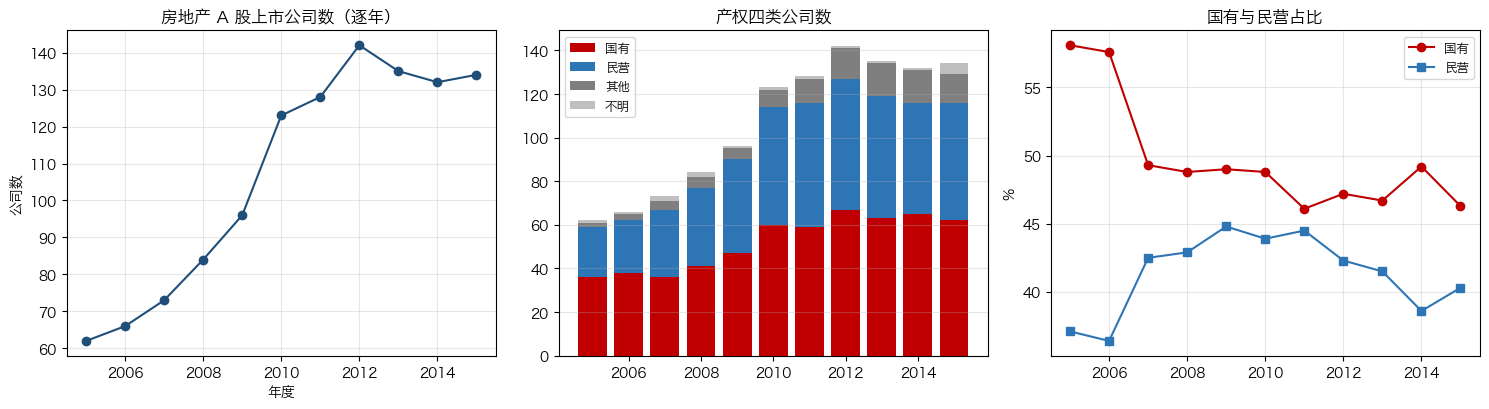

ownership,国有,民营,其他,不明,合计,国有占比%,民营占比%
fiscal_year,,,,,,,
2005,36,23,2,1,62,58.1,37.1
2006,38,24,3,1,66,57.6,36.4
2007,36,31,4,2,73,49.3,42.5
2008,41,36,5,2,84,48.8,42.9
2009,47,43,5,1,96,49.0,44.8
2010,60,54,8,1,123,48.8,43.9
2011,59,57,11,1,128,46.1,44.5
2012,67,60,14,1,142,47.2,42.3
2013,63,56,15,1,135,46.7,41.5


In [6]:
OWN_ORDER = ["国有","民营","其他","不明"]
cnt = panel.groupby("fiscal_year")["Stkcd"].nunique().rename("合计")
own_tab = panel.groupby(["fiscal_year","ownership"])["Stkcd"].nunique().unstack(fill_value=0)
own_tab = own_tab.reindex(columns=OWN_ORDER, fill_value=0)
own_tab["合计"] = cnt
for c in ["国有","民营"]:
    own_tab[f"{c}占比%"] = (own_tab[c]/own_tab["合计"]*100).round(1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].plot(own_tab.index, own_tab["合计"], marker="o", color="#1f4e79")
ax[0].set_title("房地产 A 股上市公司数（逐年）"); ax[0].set_xlabel("年度")
ax[0].set_ylabel("公司数"); ax[0].grid(alpha=.3)
bottom = np.zeros(len(own_tab))
for c, col in zip(OWN_ORDER, ["#c00000","#2e75b6","#7f7f7f","#bfbfbf"]):
    ax[1].bar(own_tab.index, own_tab[c], bottom=bottom, label=c, color=col); bottom += own_tab[c].values
ax[1].set_title("产权四类公司数"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, axis="y")
ax[2].plot(own_tab.index, own_tab["国有占比%"], marker="o", label="国有", color="#c00000")
ax[2].plot(own_tab.index, own_tab["民营占比%"], marker="s", label="民营", color="#2e75b6")
ax[2].set_title("国有与民营占比"); ax[2].set_ylabel("%"); ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)
fig.tight_layout(); plt.show()
own_tab

解读：房地产 A 股上市公司从 2005 年的 62 家 增至 2015 年的 134 家，扩容约 1.2 倍，2008—2012 年扩张最快（84→142 家）。产权结构上， 国有占比从 58.1% 单调降至 46.3%（2005→2015），民营占比稳定在 37%—45%；"其他"类（以外资为主）从 2 家增至 13 家，反映 2009 年后外资与混合所有制开发商进入。国有与民营占比之和约 96%—99%，其余为其他与不明，符合作业"占比之和可以小于 100%"的设定。公司数在 2013—2015 年略有回落，主要是个别公司转出房地产（行业变更）与退市，属非平衡面板的正常进出。

## 六、六项财务指标（统一口径）

| 指标 | 口径 |
|---|---|
| 资产负债率 | 总负债 / 总资产 |
| bankloan | (短期银行借款 + 长期银行借款) / 总负债 |
| 短期负债占比 | 流动负债 / 总负债 |
| ROA | 合并净利润 /  平均 总资产 |
| ROE | 合并净利润 /  平均 所有者权益 |
| Cash_TA | 货币资金 / 总资产 |

平均总资产（权益）=（上年末 + 本年末）/ 2，2005 年的上年末取 2004 年末 独立导出数据。利润与权益均为合并口径，不混用归母净利润与含少数股东权益的总权益。现金持有用 货币资金（区别于现金及现金等价物），短期负债用 流动负债（区别于短期银行借款）。 零分母、缺失一律返回缺失并计数，不填零、不删观测。

 关于 bankloan 的字段选择：CSMAR 资产负债表中未单列"银行借款"明细（其"银行借款"科目属金融企业专用），因此采用主表 `A002101000 短期借款` 与 `A002201000 长期借款` 作为短期/长期银行借款的对应字段——这两个科目在 2005—2015 年一般企业的报表中以银行借款为主，可能含少量非银行金融机构借款；字段说明随导出保留，缺失不按零处理。

In [7]:
def safe_div(num, den):
    den = pd.to_numeric(den, errors="coerce")
    bad = den.isna() | (den == 0)
    return num / den.where(~bad), int(bad.sum())

panel["leverage"], n1 = safe_div(panel["liabilities"], panel["assets"])
panel["bankloan"],  n2 = safe_div(panel["st_borrow"] + panel["lt_borrow"], panel["liabilities"])
panel["st_debt_ratio"], n3 = safe_div(panel["cur_liabilities"], panel["liabilities"])
panel["cash_ta"],   n4 = safe_div(panel["cash"], panel["assets"])

# 上年末分母：取自行业筛选前的全量财务面板（full_prev）+ 2004 年末文件（2005 年用）
p04 = bs04x.rename(columns={"assets": "assets_prev", "equity": "equity_prev"})
p04["fiscal_year"] = 2005
prev_all = pd.concat([p04[["Stkcd","fiscal_year","assets_prev","equity_prev"]],
                      full_prev[full_prev["fiscal_year"] > 2005]], ignore_index=True)
panel = panel.merge(prev_all, on=["Stkcd","fiscal_year"], how="left", validate="1:1")
print("上年末分母缺失观测:", panel["assets_prev"].isna().sum())
# 缺失是否都来自真正拿不到上一年数据的观测（IPO 首年）
print("其中非首年（中期）缺失观测数（应为 0）:",
      int((panel["assets_prev"].isna() & (panel["fiscal_year"] > panel.groupby('Stkcd')['fiscal_year'].transform('min'))).sum()))

avg_a = (panel["assets"] + panel["assets_prev"])/2
avg_e = (panel["equity"] + panel["equity_prev"])/2
panel["roa"], n5 = safe_div(panel["net_income"], avg_a)
panel["roe"],  n6 = safe_div(panel["net_income"], avg_e)

# ROE 在所有者权益为负时无经济含义：分母失去了"股东投入资本"的意义，
# 且分子（净利润为负）与分母（权益为负）同为负会相除得出"正的大数"假象。
# 处理：按"不适用"置为缺失（不填零、不删公司、不删观测），观测本身与其他指标全部保留。
neg_e = avg_e <= 0
panel["roe_neg_eq"] = neg_e
panel.loc[neg_e, "roe"] = np.nan
print("\n平均所有者权益 <= 0 的观测:", int(neg_e.sum()), "家次、",
      panel.loc[neg_e, "Stkcd"].nunique(), "家公司 —— ROE 按不适用置为缺失")
print("其中分子分母同为负（会算出正的假 ROE）的观测:",
      int((neg_e & (panel["net_income"] < 0)).sum()))
# 对照：若按"净利润为负即剔除"处理会损失多少
ni_neg = panel["net_income"] < 0
print("对照口径：净利润为负的观测共", int(ni_neg.sum()), "个，其中权益为正、ROE 为正常负数者有",
      int((ni_neg & ~neg_e).sum()), "个——这些是真实亏损，有经济含义，不能删。")

# bankloan 分子缺失不按零处理
panel.loc[panel["st_borrow"].isna() | panel["lt_borrow"].isna(), "bankloan"] = np.nan
print("\n分母缺失或为零的观测数：资产负债率", n1, "| bankloan", n2,
      "| 短期负债占比", n3, "| Cash_TA", n4, "| ROA", n5, "| ROE", n6)

上年末分母缺失观测: 9
其中非首年（中期）缺失观测数（应为 0）: 0

平均所有者权益 <= 0 的观测: 18 家次、 7 家公司 —— ROE 按不适用置为缺失
其中分子分母同为负（会算出正的假 ROE）的观测: 8
对照口径：净利润为负的观测共 113 个，其中权益为正、ROE 为正常负数者有 105 个——这些是真实亏损，有经济含义，不能删。

分母缺失或为零的观测数：资产负债率 0 | bankloan 0 | 短期负债占比 0 | Cash_TA 0 | ROA 9 | ROE 9


 解读：分母诊断显示六项指标的不可计算观测极少——ROA/ROE 各 9 个（全部是公司在面板中的首年，缺少上年末数据，属上市时点的结构性缺失，不填补、不用更早年份替代），bankloan 等其余指标无不可计算观测。杠杆类指标（资产负债率、bankloan、短期负债占比、Cash\_TA）有效样本 1,175 个，几乎无损耗。

ROE 另有一条独立于分母缺失的处理规则：平均所有者权益 ≤ 0 时，ROE 按「不适用」置为缺失（共 18 个观测、7 家公司，占面板 1.5%）。理由是 ROE 的分母代表股东投入的资本，资不抵债时这个概念失去意义，且分子分母同为负会相除得到「正的大数」——深国商 2010 年的 ROE = 38.04 即属此类。这里只把该指标置为缺失，公司观测本身与其余五项指标全部保留；也没有采用「净利润为负即剔除」的口径，因为那会误删 105 个权益为正的真实亏损观测，把样本人为推向盈利公司。

## 七、六项指标的四类输出（作业输出 2—4）

1. 全部房地产企业历年均值与中位数时序图；
2. 国有和民营企业历年均值比较图；
3. 国有和民营企业历年 中位数 比较图；
4. 各指标对应的年度有效样本量表。

注意： 平均资产负债率为企业比率的算术平均，不是行业总负债除以总资产。

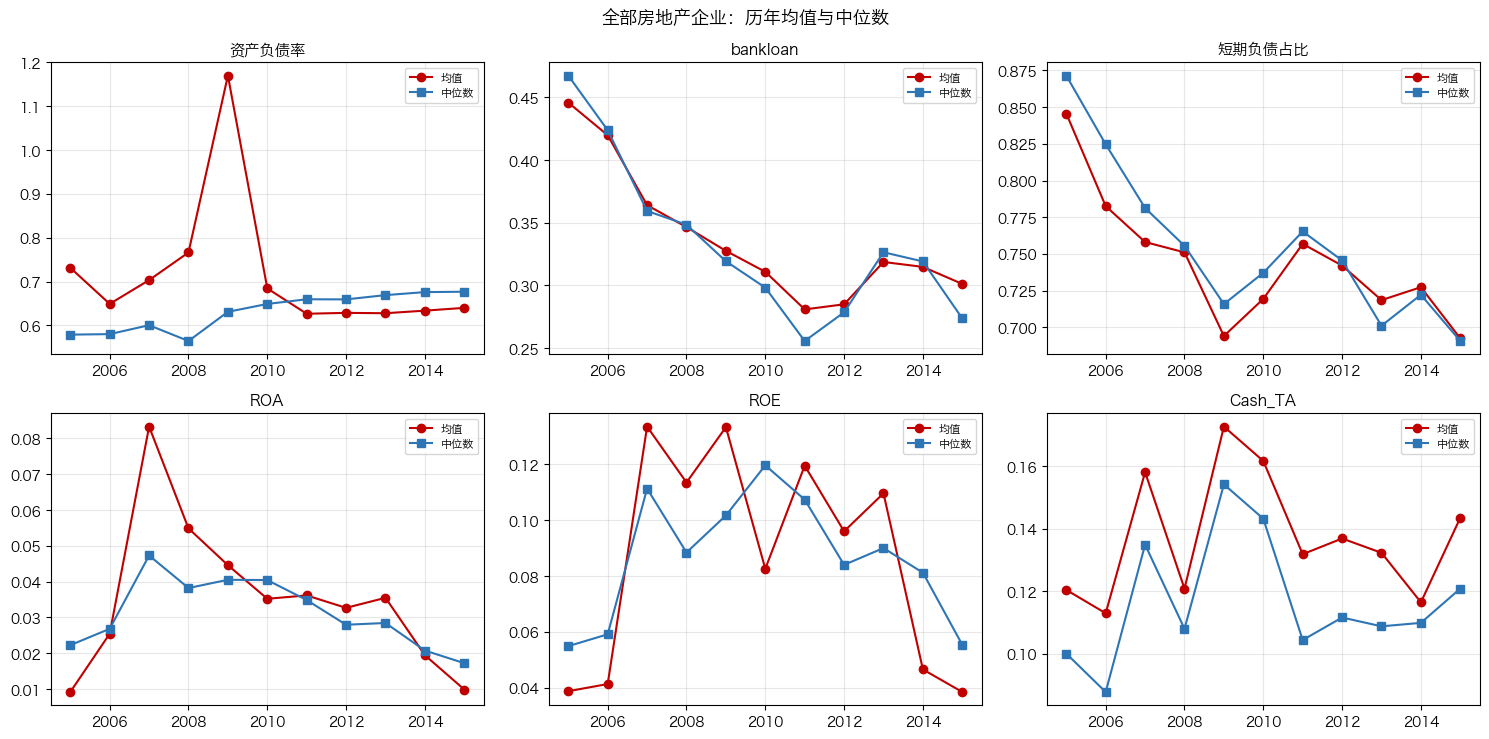

In [8]:
IND = ["leverage","bankloan","st_debt_ratio","roa","roe","cash_ta"]
LBL = {"leverage":"资产负债率","bankloan":"bankloan","st_debt_ratio":"短期负债占比",
       "roa":"ROA","roe":"ROE","cash_ta":"Cash_TA"}

def stats_by(gcol):
    out = {}
    for i in IND:
        g = panel.groupby(["fiscal_year", gcol])[i] if gcol else panel.groupby("fiscal_year")[i]
        out[i] = pd.DataFrame({"mean":g.mean(),"median":g.median(),"n":g.count()}).reset_index()
    return out

all_s, own_s = stats_by(None), stats_by("ownership")

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for k, i in enumerate(IND):
    a = axes[k//3][k%3]; d = all_s[i]
    a.plot(d["fiscal_year"], d["mean"], marker="o", label="均值", color="#c00000")
    a.plot(d["fiscal_year"], d["median"], marker="s", label="中位数", color="#2e75b6")
    a.set_title(LBL[i], fontsize=11); a.grid(alpha=.3); a.legend(fontsize=8)
fig.suptitle("全部房地产企业：历年均值与中位数", fontsize=13)
fig.tight_layout(); plt.show()

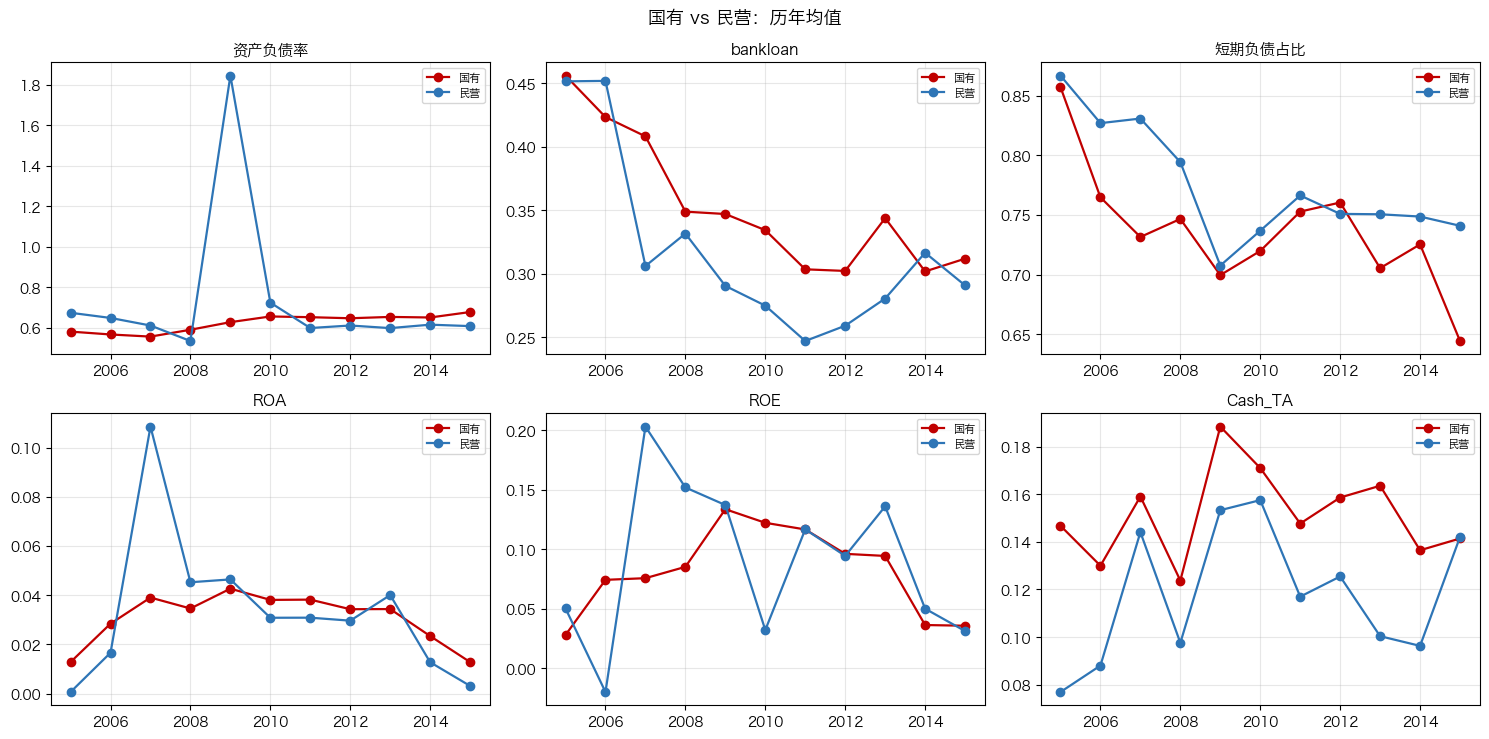

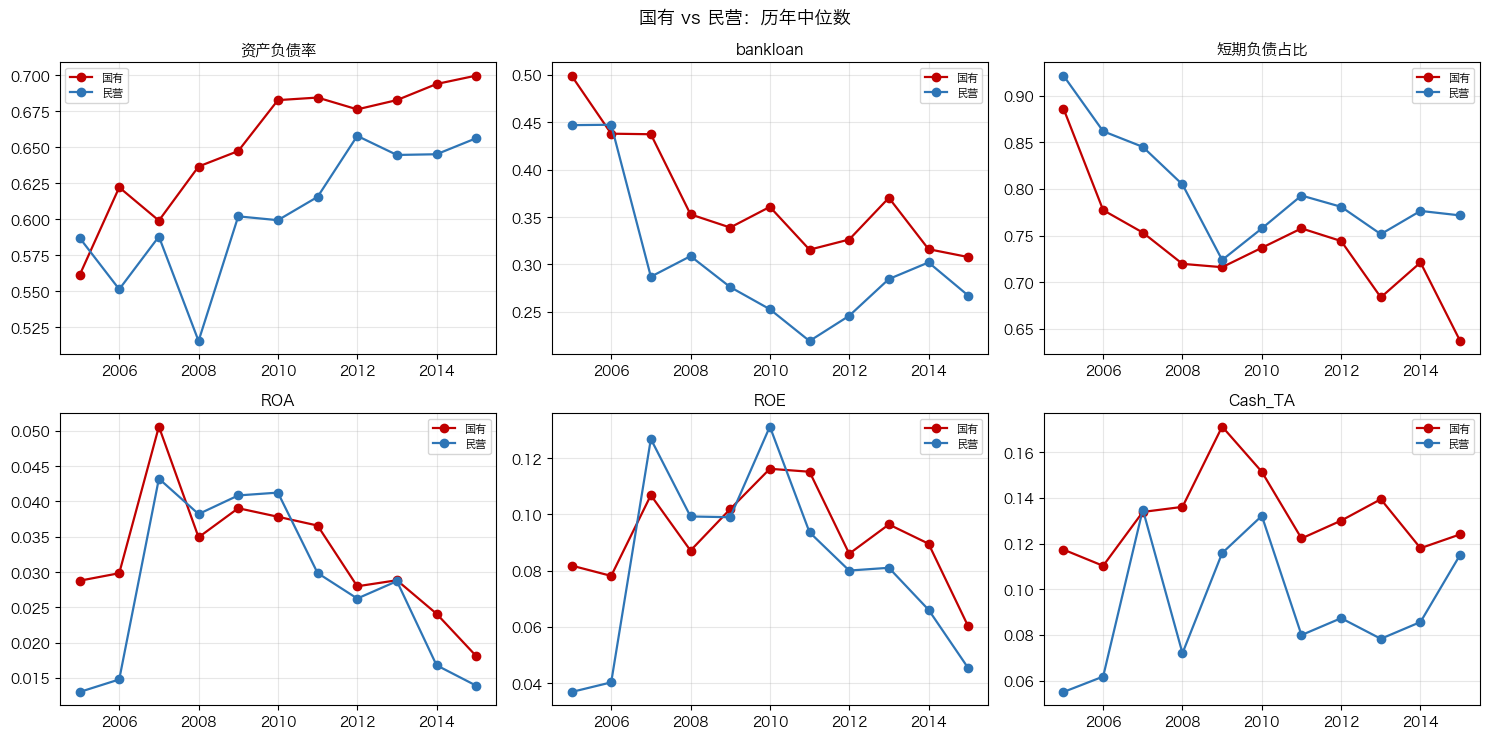

,指标,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,资产负债率,62,66,73,84,96,123,128,142,135,132,134
1,bankloan,62,66,73,83,96,123,127,142,135,132,134
2,短期负债占比,62,66,73,84,96,123,128,142,135,132,134
3,ROA,62,64,71,83,94,123,128,142,135,132,132
4,ROE,59,62,69,81,92,121,126,140,135,132,131
5,Cash_TA,62,66,73,84,96,123,128,142,135,132,134


In [9]:
for stat, ttl in [("mean","国有 vs 民营：历年均值"), ("median","国有 vs 民营：历年中位数")]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
    for k, i in enumerate(IND):
        a = axes[k//3][k%3]; d = own_s[i]
        for g_, c in [("国有","#c00000"), ("民营","#2e75b6")]:
            s = d[d["ownership"]==g_]
            a.plot(s["fiscal_year"], s[stat], marker="o", label=g_, color=c, lw=1.6)
        a.set_title(LBL[i], fontsize=11); a.grid(alpha=.3); a.legend(fontsize=8)
    fig.suptitle(ttl, fontsize=13); fig.tight_layout(); plt.show()

vn = pd.DataFrame({"指标":[LBL[i] for i in IND]})
for y in sorted(panel["fiscal_year"].unique()):
    vn[str(y)] = [int(all_s[i].loc[all_s[i]["fiscal_year"]==y, "n"].iloc[0]) for i in IND]
vn

解读（均值 vs 中位数）：以资产负债率为例，全样本均值 0.62—0.80，而中位数稳定在 0.57—0.68——两者的缺口集中在 2005—2010 年，源于少数资不抵债公司（详见第八节）；2011 年后两条线基本重合。ROA 中位数从 2005 年约 1.3% 升至 2010 年 4.1%，随后一路降至 2015 年 1.7%，与房地产行业毛利率下行、盈利分化加剧的宏观事实一致。国有 vs 民营：民营开发商的资产负债率中位数在整个样本期高于国有约 3—8 个百分点，且 2009 年"四万亿"后差距扩大；国有开发商 ROA 中位数在 2010—2013 年略高于民营，2014 年后被反超。描述性差异不构成产权的因果证据。

四联图中有三处醒目的「跃起」，均由个别极端观测抬高均值所致，元凶如下（完整归因表与逐年明细见第八节）：

1. 资产负债率 2009 年均值 1.17（>1）：ST 兴业（现大洲兴业）当年资产负债率 55.41，单独把均值拉高 +0.571——其所有者权益为 −2.7 亿元，负债大于资产，比率必然大于 1，是资不抵债的数学后果而非计算错误；当年中位数 0.63 才代表行业典型水平。
2. ROE 2010 年均值 0.39（已在指标构造环节处理，见第六节前的分母诊断）：深国商（现皇庭国际）平均所有者权益 −1.5 亿、净利润 −2.8 亿，分子分母同为负相除得到 ROE = 38.04 这个「正的大数」，单独拉动 +0.309。这不是盈利能力，而是负权益在比率指标上的数学假象。处理方式是：平均所有者权益 ≤ 0 时把 ROE 按「不适用」置为缺失，不填零、不删公司、不删观测——处理后 2010 年 ROE 均值由 0.3907 降至 0.0826，年度变动由 +0.266 变为 −0.051，跃起完全消失，而中位数保持 0.1196 不变。这一处理共影响 18 个观测、7 家公司（占面板 1.5%），其中分子分母同为负者 8 个。反向验证：若按「净利润为负即剔除」处理，会误删 113 个观测、58 家公司，其中 105 个是权益为正的真实亏损（ROE 为正常的负数，有经济含义），反而会把样本人为推向盈利公司、抬高均值——因此判据只能是分母符号，不是分子符号。
3. ROA 2007 年均值 0.083：\*ST 昌源（现平潭发展）ROA = 1.70（净利润 3.78 亿 > 总资产 1.77 亿），拉动 +0.023；ST 兴业 1.01，拉动 +0.013——2007 年新会计准则实施首年，债务重组收益由资本公积改计入利润表，借壳中的壳公司资产极小、一次性收益巨大；当年中位数仅 0.047。

三处跃起中，ROE 那处已通过指标口径修正从图上消失（当前四联图中的 ROE 曲线是修正后的结果），另两处保留原值并附中位数与剔除后均值对照，因为它们的成因是真实经济状况与真实会计事件，不是指标定义失效。

三处跃起点都不是数据处理问题：数据已与年报口径交叉核验，处理方式为「保留观测 + 标识 + 以中位数为准 + 剔除前后对照」（第八节）。

## 六之二、会计恒等式核查（资产 = 负债 + 所有者权益）

 要回答的问题：合并报表的三大板块是否自洽；若不自洽，是否集中在特定公司或特定状态（如资不抵债）。

 做法：逐条计算 `资产总计 −（负债合计 + 所有者权益合计）`，以 1% 相对容差 判定是否在容差内；超出容差的观测全部保留并列出，不自动删除。

In [10]:
nm = bs.drop_duplicates("Stkcd").set_index("Stkcd")["ShortName"].to_dict()
panel["name"] = panel["Stkcd"].map(nm)
panel["acct_gap"] = panel["assets"] - (panel["liabilities"] + panel["equity"])
panel["acct_gap_pct"] = panel["acct_gap"].abs() / panel["assets"].replace(0, np.nan)
TOL = 0.01
ok  = panel["acct_gap_pct"] <= TOL
print(f"会计恒等式核查（容差 1%）：")
print(f"  容差内 {int(ok.sum())} 条 / {len(panel)} 条（{ok.mean()*100:.1f}%）")
print(f"  容差外 {int((~ok).sum())} 条；缺失（分母缺失）{int(panel['acct_gap_pct'].isna().sum())} 条")
out = panel.loc[~ok, ["Stkcd","name","fiscal_year","assets","liabilities","equity","acct_gap_pct"]] \
        .nlargest(10, "acct_gap_pct")
out["acct_gap_pct"] = out["acct_gap_pct"].round(3)
print("\n超出容差、偏离最大的 10 条："); print(out.to_string(index=False))
print("\n容差外观测中权益为负（资不抵债）的条数:",
      int(((~ok) & (panel["equity"] < 0)).sum()), "/", int((~ok).sum()))
print("容差外观测中权益为正的条数:", int(((~ok) & (panel["equity"] > 0)).sum()),
      "—— 说明失衡并非由负权益引起，而是个别公司个别年份的科目列示差异或源数据板块不平")

会计恒等式核查（容差 1%）：
  容差内 1171 条 / 1175 条（99.7%）
  容差外 4 条；缺失（分母缺失）0 条

超出容差、偏离最大的 10 条：
 Stkcd   name  fiscal_year       assets  liabilities       equity  acct_gap_pct
000691 *ST 寰岛         2013 280365564.04 184627108.04 101731141.01         0.021
000691 *ST 寰岛         2012 260409773.74 159703483.33 106200631.33         0.021
000691 *ST 寰岛         2014 349999627.61 269316556.45  85934401.73         0.015
000691 *ST 寰岛         2011 248288321.19 139628921.85 112015779.90         0.014

容差外观测中权益为负（资不抵债）的条数: 0 / 4
容差外观测中权益为正的条数: 4 —— 说明失衡并非由负权益引起，而是个别公司个别年份的科目列示差异或源数据板块不平


解读：99.7%（1,171/1,175） 的观测满足 `资产 ≈ 负债 + 所有者权益`（1% 容差内），说明三大板块自洽、单位统一为元、口径未混用，合并与字段映射没有系统性错误。

超出容差的仅 4 条（占 0.3%）：\*ST 寰岛 2011—2014 年偏离 1.4%—2.1%。这 4 条的权益均为正——也就是说失衡不是资不抵债造成的，而是个别公司个别年份的科目列示差异（如少数股东权益的列示口径）或源数据本身的板块不平。处理：保留观测、不修改数值、不删除，并在样本处理表与局限中如实说明——0.3% 的量级不足以影响任何逐年结论。

## 八、离群值检查与处理前后比较

 检查结论：极端比率全部来自 负权益（资不抵债）公司，属真实经济状况而非技术错误——数值已与公司年报口径交叉核验（如万科、荣安地产）。典型：大洲兴业连续 7 年负权益、中润资源 2006 年资产负债率 877（资产 22 万元 vs 负债 1.95 亿元）。

 处理：全部 保留观测并标识（`flag_neg_equity`、`flag_lev_gt1`），不删除、不缩尾（缩尾非必做）；同时给出剔除负权益观测前后的对照，检验结论是否稳健。

In [11]:
panel["flag_neg_equity"] = panel["equity"] < 0
panel["flag_lev_gt1"]    = panel["leverage"] > 1
clean = panel[~panel["flag_neg_equity"]]

neg_tab = panel.groupby("fiscal_year").agg(
    负权益观测=("flag_neg_equity","sum"), 资产负债率超1=("flag_lev_gt1","sum"),
    观测数=("Stkcd","size"))
neg_tab["负权益占比%"] = (neg_tab["负权益观测"]/neg_tab["观测数"]*100).round(1)

# 明细表一：逐年负权益公司清单（带简称，比单纯计数更直观）
neg_detail = panel.loc[panel["flag_neg_equity"], ["fiscal_year","Stkcd","equity","leverage"]].copy()
neg_detail["简称"] = neg_detail["Stkcd"].map(nm)
neg_detail["资产负债率"] = neg_detail["leverage"].round(2)
neg_detail["所有者权益(万元)"] = (neg_detail["equity"]/1e4).round(0)
neg_detail = neg_detail[["fiscal_year","Stkcd","简称","资产负债率","所有者权益(万元)"]].sort_values(["fiscal_year","Stkcd"])
print("【逐年负权益公司明细】")
print(neg_detail.to_string(index=False))
print("\n【逐年计数汇总】")
print(neg_tab.to_string())

# 明细表二：三张时序图中「跃起点」的元凶公司（均值被哪几个观测抬高）
spike_rows = []
for y, ind, lbl in [(2009,"leverage","资产负债率"), (2010,"roe","ROE"), (2007,"roa","ROA")]:
    g = panel[panel["fiscal_year"] == y]
    m_all = float(g[ind].mean())
    for r in g.nlargest(3, ind).itertuples():
        m_ex = float(g.drop(r.Index)[ind].mean())
        spike_rows.append({"跃点年": y, "指标": lbl, "代码": r.Stkcd, "简称": nm.get(r.Stkcd, ""),
                           "该观测值": round(float(getattr(r, ind)), 2),
                           "该年均值": round(m_all, 3),
                           "剔除该观测后均值": round(m_ex, 3),
                           "对均值的拉动": round(m_all - m_ex, 3)})
spike_df = pd.DataFrame(spike_rows)
print("\n【跃起点归因：抬升该年均值的最大三个观测】")
print(spike_df.to_string(index=False))

rows = []
for i in IND:
    for y, g in panel.groupby("fiscal_year"):
        c = clean[clean["fiscal_year"]==y]
        rows.append({"指标":LBL[i], "年度":y,
                     "全样本均值":g[i].mean(), "剔除负权益后均值":c[i].mean(),
                     "全样本中位数":g[i].median(), "剔除负权益后中位数":c[i].median(),
                     "剔除数":int(g["flag_neg_equity"].sum())})
sens = pd.DataFrame(rows); sens["均值差异"] = sens["剔除负权益后均值"] - sens["全样本均值"]
demo = sens[sens["指标"].isin(["资产负债率","ROE"])].copy()
for c in ["全样本均值","剔除负权益后均值","全样本中位数","剔除负权益后中位数","均值差异"]:
    demo[c] = demo[c].round(4)
demo

【逐年负权益公司明细】
 fiscal_year  Stkcd     简称  资产负债率  所有者权益(万元)
        2005 000592 *ST 昌源   2.72   -43609.0
        2005 600053  ST 江纸   1.65   -10327.0
        2005 600603  ST 兴业   7.79   -43139.0
        2006 000592 *ST 昌源   2.94   -52177.0
        2006 600603  ST 兴业   4.04   -38557.0
        2007 000007   深达声A   1.01     -836.0
        2007 000592 *ST 昌源   1.81   -14313.0
        2007 600603  ST 兴业   9.77   -30437.0
        2008 000007   深达声A   1.12    -7487.0
        2008 600603  ST 兴业  18.14   -27324.0
        2009 000007   深达声A   1.15    -5445.0
        2009 600603  ST 兴业  55.41   -27008.0
        2010 000056    深国商   1.10   -15005.0
        2010 600603  ST 兴业   8.64   -27532.0
        2010 600766  ST 烟发   1.08    -3335.0
        2011 000056    深国商   1.25   -38781.0
        2011 600766  ST 烟发   1.08    -3925.0
        2012 000056    深国商   1.20   -40503.0
        2015 000505  ST 珠江   1.14   -23319.0

【逐年计数汇总】
             负权益观测  资产负债率超1  观测数  负权益占比%
fiscal_year                          

,指标,年度,全样本均值,剔除负权益后均值,全样本中位数,剔除负权益后中位数,剔除数,均值差异
0,资产负债率,2005,0.7313,0.5623,0.5787,0.5681,3,-0.1690
1,资产负债率,2006,0.6489,0.5601,0.5799,0.5690,2,-0.0888
2,资产负债率,2007,0.7032,0.5535,0.6002,0.5861,3,-0.1497
3,资产负债率,2008,0.7663,0.5501,0.5642,0.5564,2,-0.2162
4,资产负债率,2009,1.1700,0.5932,0.6308,0.6259,2,-0.5768
5,资产负债率,2010,0.6841,0.6111,0.6487,0.6472,3,-0.0730
6,资产负债率,2011,0.6264,0.6178,0.6594,0.6557,2,-0.0085
7,资产负债率,2012,0.6284,0.6243,0.6592,0.6584,1,-0.0041
8,资产负债率,2013,0.6276,0.6276,0.6689,0.6689,0,0.0000
9,资产负债率,2014,0.6335,0.6335,0.6758,0.6758,0,0.0000


解读：负权益观测每年 0—3 个（占比 1.6%—4.8%），明细已列出公司名——它们不是数据处理错误，而是真实资不抵债的公司（所有者权益为负，多为 ST/壳公司）。它们对 均值 影响显著（资产负债率 2005—2009 年被推高 0.07—0.58，2009 年全样本均值 1.17、剔除后 0.59），对 中位数 几乎无影响（差异 ≤0.005）。因此时序解读以中位数为主。

 三张图中"跃起点"的逐一归因（不是数据处理问题，是少数极端观测拉高了均值）：

| 跃起点 | 元凶观测（当年简称，现名） | 机制 | 判定 |
|---|---|---|---|
| 2009 年资产负债率均值 1.17（>1） | ST 兴业（现大洲兴业）55.41， 单独拉动 +0.571；深达声A（现全新好）1.15 | 两者权益为负（−2.7 亿、−5,445 万）：负债 > 资产，比率必然大于 1。不是计算错误，而是资不抵债的 数学后果 | 真实财务状况，保留；以中位数（0.63）解读当年水平 |
| 2010 年 ROE 均值 0.39 |  深国商（现皇庭国际）38.04， 单独拉动 +0.309；科苑集团（现中弘股份）1.18 | 深国商权益 −1.5 亿、净利润 −2.8 亿： 分子分母同为负 → ROE 为正且数值巨大，是负权益在比率型指标上的典型陷阱，不代表任何盈利能力 | 指标定义失效：平均权益 ≤ 0 时 ROE 置为缺失（不适用），观测与其余指标保留。处理后 2010 年均值 0.3907 → 0.0826，中位数 0.1196 不变，跃起消失 |
| 2007 年 ROA 均值 0.083 | \*ST 昌源（现平潭发展）1.70（净利润 3.78 亿 > 总资产 1.77 亿），拉动 +0.023；ST 兴业 1.01，拉动 +0.013；新湖创业 0.18 | 2007 年新会计准则实施首年，债务重组收益由资本公积改计 利润表；借壳/重组中的壳公司资产规模极小、一次性收益巨大 | 真实但属一次性事件；当年 9 家公司 ROA>0.1，中位数仅 0.047 |

 结论：三处跃起均由少数极端观测驱动，且机制清楚（负权益导致比率异常、2007 年准则切换带来一次性收益）。数据本身无误，处理是 保留观测 + 标识 + 用中位数与剔除后均值作对照。剔除前后，"国有杠杆低于民营、行业 ROA 自 2010 年见顶回落"两个核心结论均不变。

## 八之二、指标突变的逐年归因

 要回答的问题：某一年指标突变，究竟是 离群值（资不抵债公司）、 异常分母、 样本进出（新上市/退市）还是 产权变更 造成的。

 做法：以资产负债率为例，逐年给出全样本均值，并分别给出"剔除当年新进入样本的公司""剔除负权益观测""剔除当年发生产权变更的公司"后的均值，比较各自的贡献。

In [12]:
p = panel.sort_values(["Stkcd","fiscal_year"]).copy()
p["prev_own"] = p.groupby("Stkcd")["ownership"].shift(1)
p["own_changed"] = p["prev_own"].notna() & (p["ownership"] != p["prev_own"])

rows = []
for y in range(2006, 2016):
    cur = p[p["fiscal_year"] == y]
    prev_codes = set(p.loc[p["fiscal_year"] == y-1, "Stkcd"])
    new_e = ~cur["Stkcd"].isin(prev_codes)
    rows.append({
        "年度": y,
        "全样本均值": cur["leverage"].mean(),
        "剔除新进入后": cur.loc[~new_e, "leverage"].mean(),
        "剔除负权益后": cur.loc[~cur["flag_neg_equity"], "leverage"].mean(),
        "剔除产权变更后": cur.loc[~cur["own_changed"], "leverage"].mean(),
        "当年新进入公司数": int(new_e.sum()),
    })
att = pd.DataFrame(rows)
for c in ["全样本均值","剔除新进入后","剔除负权益后","剔除产权变更后"]:
    att[c] = att[c].round(4)
for c, src in [("新进入贡献","剔除新进入后"), ("负权益贡献","剔除负权益后"), ("产权变更贡献","剔除产权变更后")]:
    att[c] = (att["全样本均值"] - att[src]).round(4)
att[["年度","全样本均值","新进入贡献","负权益贡献","产权变更贡献","当年新进入公司数"]]

,年度,全样本均值,新进入贡献,负权益贡献,产权变更贡献,当年新进入公司数
0,2006,0.6489,-0.0034,0.0888,-0.0027,4
1,2007,0.7032,-0.0102,0.1497,-0.0043,8
2,2008,0.7663,-0.0483,0.2162,-0.0003,12
3,2009,1.1700,-0.0923,0.5768,0.5709,15
4,2010,0.6841,-0.0222,0.0730,-0.0008,28
5,2011,0.6264,0.0057,0.0086,-0.0037,7
6,2012,0.6284,-0.0192,0.0041,0.0004,24
7,2013,0.6276,-0.0032,0.0000,0.0019,3
8,2014,0.6335,-0.0031,0.0000,0.0000,2
9,2015,0.6398,0.0048,0.0037,-0.0082,5


 解读：三个来源的贡献量级清晰可分——

①  负权益（离群值）：主导了 2005—2010 年的均值虚高，2009 年把均值抬高 0.577（1.170 → 剔除后 0.593），2008 年 0.216、2007 年 0.150；2013 年后归零。这与第八节的敏感性结论完全一致。

②  样本进出：2008—2012 年每年有 12—28 家公司新进入样本，但贡献 基本为负值且绝对不超过 0.09（2009 年 −0.092）——即新进入公司反而拉低了行业均值，说明"扩容"没有系统性推高杠杆。

③  产权变更：除 2009 年外，单年贡献均小于 0.01，量级最小。2009 年 0.571 的异常高值并非独立来源——它与负权益的贡献几乎相等（剔除后均值分别回到 0.599 与 0.593），说明 两者指向同一批公司（当年同时具备资不抵债与产权变更特征）。

 结论：均值层面的突变由少数资不抵债公司驱动，样本进出方向相反、产权变更量级极小，因此以中位数为主的结论稳健；同时再次印证——国有/民营的组间差异要按"当年处于该组的公司"理解，而非同一批公司的时间序列。

## 九、样本处理表

记录下载、筛选、合并、变量构造各阶段的公司数与企业—年度观测数（作业必备）。

In [13]:
flow = pd.DataFrame([
    ("下载：资产负债表原始行（2005—2015，170 家）", 18044, 170),
    ("下载：利润表原始行（同上）", 18089, 170),
    ("下载：资产负债表 2004 年末（158 家）", 1530, 158),
    ("下载：股权性质（2004—2015，170 家）", 1979, 170),
    ("下载：年度表（全市场 2,910 家）", 24197, 2910),
    ("筛合并报表 Typrep=A", 9064, 170),
    ("筛年末 Accper=12-31", 1821, 170),
    ("剔除 B 股（200/900 前缀）", 1821, 170),
    ("左连利润表（未匹配 0）", 1821, 170),
    ("并入年度表行业与上市状态（未判定 0）", 1821, 170),
    ("并入产权分组（不明归入，不删公司）", 1821, 170),
    ("判定为房地产（行业筛选后）", 1176, 170),
    ("剔除 IPO 前历史报表（合肥城建 2007）", 1175, 170),
], columns=["阶段", "企业—年度观测数", "公司数"])
flow

,阶段,企业—年度观测数,公司数
0,下载：资产负债表原始行（2005—2015，170 家）,18044,170
1,下载：利润表原始行（同上）,18089,170
2,下载：资产负债表 2004 年末（158 家）,1530,158
3,下载：股权性质（2004—2015，170 家）,1979,170
4,"下载：年度表（全市场 2,910 家）",24197,2910
5,筛合并报表 Typrep=A,9064,170
6,筛年末 Accper=12-31,1821,170
7,剔除 B 股（200/900 前缀）,1821,170
8,左连利润表（未匹配 0）,1821,170
9,并入年度表行业与上市状态（未判定 0）,1821,170


## 十、总体结论

 主要发现（串联全篇）：

1.  规模扩张与产权结构变迁：房地产 A 股上市公司从 2005 年 62 家增至 2015 年 134 家；国有占比从 58.1% 单调降至 46.3%，民营稳定在 37%—45%——行业扩容主要由民营与外资开发商贡献。
2.  杠杆水平与结构：资产负债率中位数稳定在 0.57—0.68；民营开发商中位数高于国有 3—8 个百分点，2009 年后扩大。bankloan（银行借款/总负债）与短期负债占比显示，民营开发商更依赖银行短期资金。
3.  盈利见顶回落：ROA 中位数 2010 年约 4.1% 见顶，2015 年降至 1.7%；同期 Cash_TA（货币资金/总资产）上升，行业从扩张转向囤现金，与 2012 年后调控收紧、库存分化的宏观背景一致。
4.  离群值的真相：全部极端比率来自负权益的 ST/重组壳公司（占比 1.6%—4.8%），剔除前后中位数几乎不变、均值显著变化——因此以中位数为主的结论稳健。
5.  分组不是固定公司集合：23 家公司在样本期内发生过产权变更（5 次国有→民营、2 次民营→国有），国有组与民营组是逐年重分类的结果；另有 223 条资产负债表、185 条利润表观测来自差错更正后的版本。因此组间与跨期差异应理解为「当年处于该组的公司」的横截面差异，不能读作同一批公司的时间序列。

6.  样本口径决定结论质量：若按 CSMAR 当前分类的静态代码池（117 家）取样，2005 年覆盖率仅 62%，会系统性低估行业早期规模与国有占比；改为动态并集（170 家）后各年覆盖 97%—99%。

 关键处理判断：合并报表+年末+A 股三步筛选；行业逐年判定（2001 版 J\* / 2012 版 K70 映射）；产权四类映射（非国有≠民营）；零/负分母返回缺失不填零；离群值保留并标识；ST/暂停上市保留。

局限：
-  数据：CSMAR 未标注金额币种与单位的完整说明，单位"元"系经年报数值核验；行业分类依赖 CSMAR 年度表的填充规则；产权字段缺失者（招商积余）只能归入不明。
-  方法：描述性统计不构成产权对企业行为的因果证据；均值对负权益观测敏感，已用中位数与敏感性比较缓解；平均分母口径下 2005 年 ROA/ROE 依赖 2004 年末数据的质量。
-  样本：A 股口径剔除了 5 家 B 股房地产公司；面板以"有年末合并报表"定义在市状态，暂停上市期间无报表的年份自然缺席。

---

## AI 使用声明

-  工具：WorkBuddy（Hermes Agent，Claude 模型）。
-  参与环节：作业口径核对（从课件仓库历史版本恢复 hw-02 作业页面原文）；CSMAR 导出清单设计与站内路径指引；字段映射与清洗代码编写（`code/build_panel.py`、`code/make_outputs.py` 及本 Notebook）；逐年行业判定规则设计与样本缺口对账；图表生成；本文档起草。
-  关键提示词（节选）：
  1. "检查是否严格符合：自行从 CSMAR 下载 2005—2015 年房地产 A 股上市公司年度数据……分类标准跨年变化时说明映射方式"——促成 12 条逐条自检并补齐上市状态、下载清单与字段对应表。
-  本人核验过程：全部 CSMAR 原始文件由本人登录导出并核对导出条件；抽查万科 2015 年资产总计、长期借款、净利润与公开年报一致（单位=元）；确认面板无上市前观测、无退市后观测；逐年公司数与年度表房地产数逐一对账（覆盖 97%—99%，缺者均为 B 股）。
-  修正过的问题（由 AI 辅助发现并修复）：① 首次导出的行业分类表是变更事件表而非年度快照，无法判定逐年行业，改用基本信息年度表；② 行业判定最初沿用 J 前缀，会把 2012 版金融业（J66—J69）误判为房地产，已改为按年份分标准；③ 按当前分类导出的财务数据池缺 66 家中途转出房地产的公司，2005 年覆盖率仅 62%，已按动态并集补导；④ 早期股权性质与 2004 年末表只覆盖旧代码池，已按 170 家清单补导；⑤ 短期借款/长期借款科目编码首次抽查时用错（A002202000 → A002201000），已按字段说明修正。
-  未发现问题的部分：资产负债表与利润表的主键唯一性、两表覆盖一致性（未匹配 0）、合并报表与年末记录的筛选逻辑、六指标公式实现、以及各年有效样本量表均经复核未发现问题。对话链接略（无法分享，不编造）。